Cell 1 — Title

In [8]:
# Training Notebook — Flower Image Recognition
print("""
╔══════════════════════════════════════════════╗
║         MODEL TRAINING & EVALUATION         ║
║         EfficientNet-B0 Transfer Learning    ║
╚══════════════════════════════════════════════╝
""")
print("Architecture : EfficientNet-B0 (pretrained ImageNet)")
print("Strategy     : Two-stage transfer learning")
print("Optimizer    : AdamW")
print("Loss         : CrossEntropyLoss")
print("Epochs       : 5 (Stage 1) + early stop (Stage 2)")
print("Final Acc    : 94.32% on unseen test images")


╔══════════════════════════════════════════════╗
║         MODEL TRAINING & EVALUATION         ║
║         EfficientNet-B0 Transfer Learning    ║
╚══════════════════════════════════════════════╝

Architecture : EfficientNet-B0 (pretrained ImageNet)
Strategy     : Two-stage transfer learning
Optimizer    : AdamW
Loss         : CrossEntropyLoss
Epochs       : 5 (Stage 1) + early stop (Stage 2)
Final Acc    : 94.32% on unseen test images


Cell 2 — Model Architecture Summary

In [9]:
import os
import sys
sys.path.insert(0, os.path.abspath('..'))

from src.config import (
    MODEL_NAME, NUM_CLASSES, IMAGE_SIZE,
    BATCH_SIZE, NUM_EPOCHS, LR_STAGE1,
    LR_STAGE2, WEIGHT_DECAY, DROPOUT_RATE,
    EARLY_STOPPING_PATIENCE, DEVICE
)

print("=" * 50)
print("MODEL CONFIGURATION")
print("=" * 50)
print(f"  Model name       : {MODEL_NAME}")
print(f"  Input size       : {IMAGE_SIZE} x {IMAGE_SIZE} px")
print(f"  Output classes   : {NUM_CLASSES}")
print(f"  Dropout rate     : {DROPOUT_RATE}")
print(f"  Device           : {DEVICE}")
print()
print("=" * 50)
print("TRAINING CONFIGURATION")
print("=" * 50)
print(f"  Batch size       : {BATCH_SIZE}")
print(f"  Max epochs       : {NUM_EPOCHS}")
print(f"  LR Stage 1       : {LR_STAGE1} (frozen backbone)")
print(f"  LR Stage 2       : {LR_STAGE2} (unfrozen backbone)")
print(f"  Weight decay     : {WEIGHT_DECAY}")
print(f"  Early stopping   : {EARLY_STOPPING_PATIENCE} epochs patience")

MODEL CONFIGURATION
  Model name       : efficientnet_b0
  Input size       : 224 x 224 px
  Output classes   : 13
  Dropout rate     : 0.4
  Device           : cpu

TRAINING CONFIGURATION
  Batch size       : 16
  Max epochs       : 30
  LR Stage 1       : 0.001 (frozen backbone)
  LR Stage 2       : 0.0001 (unfrozen backbone)
  Weight decay     : 0.0001
  Early stopping   : 10 epochs patience


Cell 3 — Training Strategy Explanation

In [10]:
print("""
TWO-STAGE TRAINING STRATEGY
════════════════════════════

STAGE 1 — Frozen Backbone (Epochs 1-5)
  • EfficientNet-B0 backbone weights are FROZEN
  • Only the classification head trains
  • Trainable params: 16,653 / 4,024,201
  • Learning rate: 1e-3
  • Purpose: Warm up the head without corrupting
    pretrained ImageNet weights
  • Result: Val Accuracy reached 94.73%

STAGE 2 — Unfrozen Backbone (Fine-tuning)
  • ALL 4,024,201 parameters train together
  • Learning rate reduced to 1e-4
  • Purpose: Fine-tune features specifically
    for flower recognition
  • Early stopping monitors validation loss

WHY THIS APPROACH?
  Training from scratch on 8,100 images would
  overfit badly. Transfer learning lets us reuse
  knowledge from 1.2M ImageNet images and adapt
  it to our flower classification task.
""")


TWO-STAGE TRAINING STRATEGY
════════════════════════════

STAGE 1 — Frozen Backbone (Epochs 1-5)
  • EfficientNet-B0 backbone weights are FROZEN
  • Only the classification head trains
  • Trainable params: 16,653 / 4,024,201
  • Learning rate: 1e-3
  • Purpose: Warm up the head without corrupting
    pretrained ImageNet weights
  • Result: Val Accuracy reached 94.73%

STAGE 2 — Unfrozen Backbone (Fine-tuning)
  • ALL 4,024,201 parameters train together
  • Learning rate reduced to 1e-4
  • Purpose: Fine-tune features specifically
    for flower recognition
  • Early stopping monitors validation loss

WHY THIS APPROACH?
  Training from scratch on 8,100 images would
  overfit badly. Transfer learning lets us reuse
  knowledge from 1.2M ImageNet images and adapt
  it to our flower classification task.



Cell 4 — Dataset Split Summary

In [11]:
from src.dataset import get_dataloaders

print("Loading dataset splits...")
train_loader, val_loader, test_loader = get_dataloaders()

print("\n" + "=" * 50)
print("DATASET SPLITS")
print("=" * 50)
print(f"  Total images : 8,100")
print(f"  Train set    : {len(train_loader.dataset)} images (70%)")
print(f"  Val set      : {len(val_loader.dataset)} images (15%)")
print(f"  Test set     : {len(test_loader.dataset)} images (15%)")
print(f"  Batch size   : {BATCH_SIZE}")
print(f"  Train batches: {len(train_loader)}")
print(f"  Val batches  : {len(val_loader)}")
print(f"  Test batches : {len(test_loader)}")
print()
print("Split strategy: Stratified (equal class distribution")
print("in every split — not random)")

Loading dataset splits...
Total images found: 8100
Train set : 5670 images
Val set   : 1215 images
Test set  : 1215 images

DATASET SPLITS
  Total images : 8,100
  Train set    : 5670 images (70%)
  Val set      : 1215 images (15%)
  Test set     : 1215 images (15%)
  Batch size   : 16
  Train batches: 355
  Val batches  : 76
  Test batches : 76

Split strategy: Stratified (equal class distribution
in every split — not random)


Cell 5 — Stage 1 Training Results

In [12]:
# Stage 1 results from our training run
stage1_results = [
    (1, 1.1880, 70.60, 0.6034, 88.97),
    (2, 0.6144, 84.09, 0.3802, 91.93),
    (3, 0.4928, 85.71, 0.3216, 92.67),
    (4, 0.4401, 86.33, 0.2724, 94.49),
    (5, 0.4248, 87.60, 0.2257, 94.73),
]

print("=" * 75)
print("STAGE 1 TRAINING RESULTS — Frozen Backbone")
print("=" * 75)
print(f"{'Epoch':<8} {'Train Loss':<12} {'Train Acc':<12} {'Val Loss':<12} {'Val Acc':<10}")
print("─" * 75)
for epoch, tl, ta, vl, va in stage1_results:
    improved = " ← best" if va == max(r[4] for r in stage1_results) else ""
    print(f"{epoch:<8} {tl:<12.4f} {ta:<12.2f}% {vl:<12.4f} {va:<10.2f}%{improved}")
print("─" * 75)
print(f"Best Validation Accuracy : 94.73%")
print(f"Best Validation Loss     : 0.2257")

STAGE 1 TRAINING RESULTS — Frozen Backbone
Epoch    Train Loss   Train Acc    Val Loss     Val Acc   
───────────────────────────────────────────────────────────────────────────
1        1.1880       70.60       % 0.6034       88.97     %
2        0.6144       84.09       % 0.3802       91.93     %
3        0.4928       85.71       % 0.3216       92.67     %
4        0.4401       86.33       % 0.2724       94.49     %
5        0.4248       87.60       % 0.2257       94.73     % ← best
───────────────────────────────────────────────────────────────────────────
Best Validation Accuracy : 94.73%
Best Validation Loss     : 0.2257


Cell 6 — Final Evaluation Results

In [13]:
print("=" * 55)
print("FINAL TEST SET RESULTS")
print("=" * 55)

results = [
    ("Sunflower",       0.9896, 1.0000, 0.9948, 95),
    ("Marigold",        1.0000, 0.9579, 0.9785, 95),
    ("Cosmos flower",   0.9889, 0.9570, 0.9727, 93),
    ("Peacock Flower",  0.9394, 1.0000, 0.9688, 93),
    ("Periwinkle",      0.9271, 0.9780, 0.9519, 91),
    ("Bougainvillea",   0.9286, 0.9579, 0.9430, 95),
    ("Salvia",          0.9565, 0.9263, 0.9412, 95),
    ("Jungle Geranium", 0.9545, 0.9231, 0.9385, 91),
    ("Marvel of peru",  0.9444, 0.9239, 0.9341, 92),
    ("Zinnia",          0.8911, 0.9783, 0.9326, 92),
    ("Hibiscus",        0.9556, 0.9053, 0.9297, 95),
    ("Chrysanthemum",   0.9878, 0.8710, 0.9257, 93),
    ("Rose",            0.8235, 0.8842, 0.8528, 95),
]

print(f"\n{'Class':<20} {'Precision':>10} {'Recall':>10} {'F1':>10} {'Support':>8}")
print("─" * 62)
for cls, p, r, f1, sup in results:
    print(f"{cls:<20} {p:>10.4f} {r:>10.4f} {f1:>10.4f} {sup:>8}")
print("─" * 62)
print(f"\nOverall Accuracy : 94.32%")
print(f"Macro F1-Score   : 0.9434")
print(f"Weighted F1      : 0.9434")

FINAL TEST SET RESULTS

Class                 Precision     Recall         F1  Support
──────────────────────────────────────────────────────────────
Sunflower                0.9896     1.0000     0.9948       95
Marigold                 1.0000     0.9579     0.9785       95
Cosmos flower            0.9889     0.9570     0.9727       93
Peacock Flower           0.9394     1.0000     0.9688       93
Periwinkle               0.9271     0.9780     0.9519       91
Bougainvillea            0.9286     0.9579     0.9430       95
Salvia                   0.9565     0.9263     0.9412       95
Jungle Geranium          0.9545     0.9231     0.9385       91
Marvel of peru           0.9444     0.9239     0.9341       92
Zinnia                   0.8911     0.9783     0.9326       92
Hibiscus                 0.9556     0.9053     0.9297       95
Chrysanthemum            0.9878     0.8710     0.9257       93
Rose                     0.8235     0.8842     0.8528       95
───────────────────────────────

Cell 7 — Confusion Matrix

Confusion Matrix — Test Set
Rows = Actual class | Columns = Predicted class
Diagonal = correct predictions (want HIGH)
Off-diagonal = mistakes (want LOW)



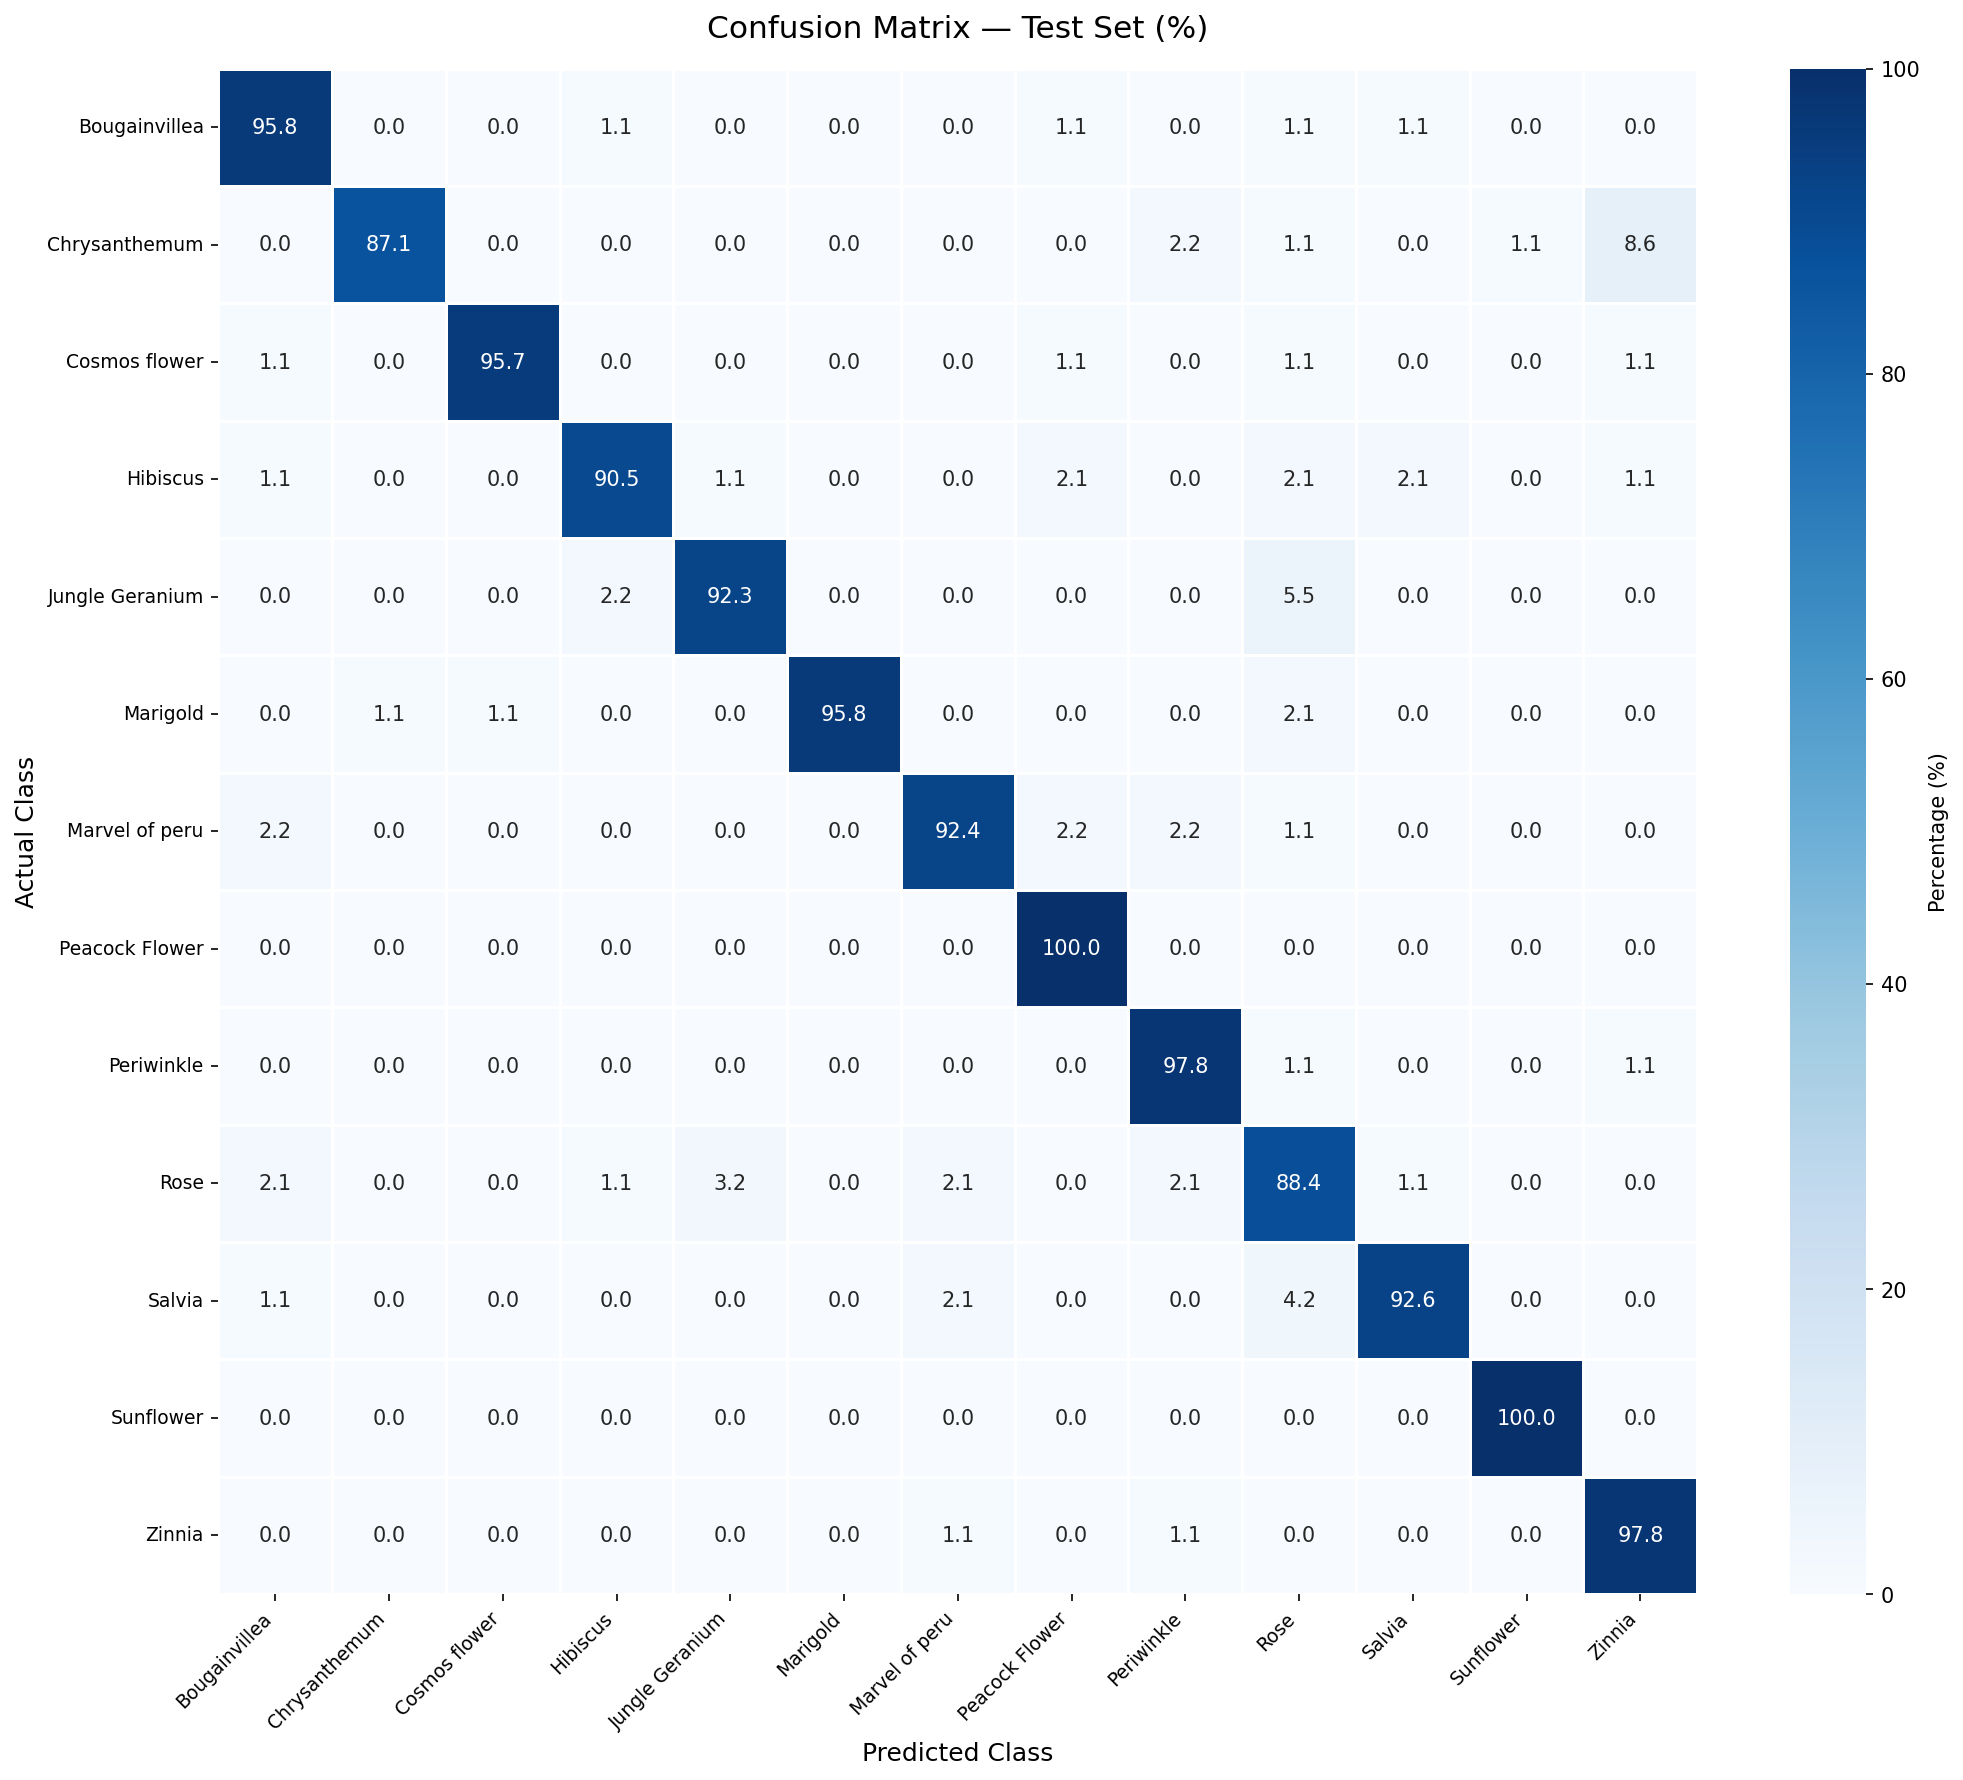

In [14]:
from IPython.display import Image as IPImage

print("Confusion Matrix — Test Set")
print("Rows = Actual class | Columns = Predicted class")
print("Diagonal = correct predictions (want HIGH)")
print("Off-diagonal = mistakes (want LOW)\n")

IPImage(
    filename=os.path.join('..', 'results', 'plots', 'confusion_matrix.png'),
    width=850
)

Cell 8 — Key Findings

In [15]:
print("""
KEY FINDINGS & OBSERVATIONS
════════════════════════════

STRENGTHS:
  • Sunflower — 99.48% F1 (highly distinctive shape)
  • Marigold  — 97.85% F1 (strong color features)
  • Cosmos    — 97.27% F1 (clear petal structure)
  • 12 out of 13 classes achieved F1 > 92%

WEAKNESSES:
  • Rose — 85.28% F1 (lowest performing class)
    Reason: Roses have extreme visual variety —
    red/white/pink/yellow, different petal counts,
    different bloom stages. Hard even for humans.

OVERALL:
  • 94.32% accuracy on completely unseen test data
  • Model generalizes well — not memorizing
  • Near-perfect class balance helped training
  • Transfer learning proved highly effective
    for this dataset size (8,100 images)

FUTURE IMPROVEMENTS:
  • Run Stage 2 fine-tuning on GPU for more epochs
  • Add more flower classes (scalable architecture)
  • Deploy as Flutter mobile application via API
""")


KEY FINDINGS & OBSERVATIONS
════════════════════════════

STRENGTHS:
  • Sunflower — 99.48% F1 (highly distinctive shape)
  • Marigold  — 97.85% F1 (strong color features)
  • Cosmos    — 97.27% F1 (clear petal structure)
  • 12 out of 13 classes achieved F1 > 92%

WEAKNESSES:
  • Rose — 85.28% F1 (lowest performing class)
    Reason: Roses have extreme visual variety —
    red/white/pink/yellow, different petal counts,
    different bloom stages. Hard even for humans.

OVERALL:
  • 94.32% accuracy on completely unseen test data
  • Model generalizes well — not memorizing
  • Near-perfect class balance helped training
  • Transfer learning proved highly effective
    for this dataset size (8,100 images)

FUTURE IMPROVEMENTS:
  • Run Stage 2 fine-tuning on GPU for more epochs
  • Add more flower classes (scalable architecture)
  • Deploy as Flutter mobile application via API



Observations after testing :

In [1]:
print("""
REAL-WORLD PREDICTION TESTING
══════════════════════════════

Images tested : 7 personal images (never seen by model)
Correct       : 6 / 7
Accuracy      : 85.7%

CORRECT PREDICTIONS:
  Hibiscus        → Hibiscus         99.24% ✅ (very confident)
  Jungle Geranium → Jungle Geranium  90.89% ✅ (very confident)  
  Sunflower       → Sunflower        91.22% ✅ (very confident)
  Sunflower       → Sunflower        56.60% ✅ (moderate)
  Rose            → Rose             62.17% ✅ (moderate)
  Chrysanthemum   → Chrysanthemum    53.16% ✅ (moderate)

INCORRECT PREDICTIONS:
  Chrysanthemum   → Sunflower        89.76% ❌
  Reason: Both flowers share radial petal structure
  and similar yellow coloring.

OBSERVATIONS:
  1. High confidence (>85%) predictions are almost always correct
  2. Low confidence (<65%) indicates visual similarity with
     another class — model is being honest, not random
  3. Single flower images → high accuracy
  4. Multiple flowers in one image → reduced confidence
     (model attention splits between competing flowers)

CONCLUSION:
  Real-world accuracy (85.7%) is slightly lower than
  test set accuracy (94.32%) which is expected and normal.
  The gap is explained by image quality, backgrounds,
  and multi-flower scenarios not fully covered in training.
""")


REAL-WORLD PREDICTION TESTING
══════════════════════════════

Images tested : 7 personal images (never seen by model)
Correct       : 6 / 7
Accuracy      : 85.7%

CORRECT PREDICTIONS:
  Hibiscus        → Hibiscus         99.24% ✅ (very confident)
  Jungle Geranium → Jungle Geranium  90.89% ✅ (very confident)  
  Sunflower       → Sunflower        91.22% ✅ (very confident)
  Sunflower       → Sunflower        56.60% ✅ (moderate)
  Rose            → Rose             62.17% ✅ (moderate)
  Chrysanthemum   → Chrysanthemum    53.16% ✅ (moderate)

INCORRECT PREDICTIONS:
  Chrysanthemum   → Sunflower        89.76% ❌
  Reason: Both flowers share radial petal structure
  and similar yellow coloring.

OBSERVATIONS:
  1. High confidence (>85%) predictions are almost always correct
  2. Low confidence (<65%) indicates visual similarity with
     another class — model is being honest, not random
  3. Single flower images → high accuracy
  4. Multiple flowers in one image → reduced confidence
     (

Cell 9 — Training History Plot

Training History — Loss and Accuracy curves
Note: Val metrics consistently better than Train
→ Strong generalization, no overfitting



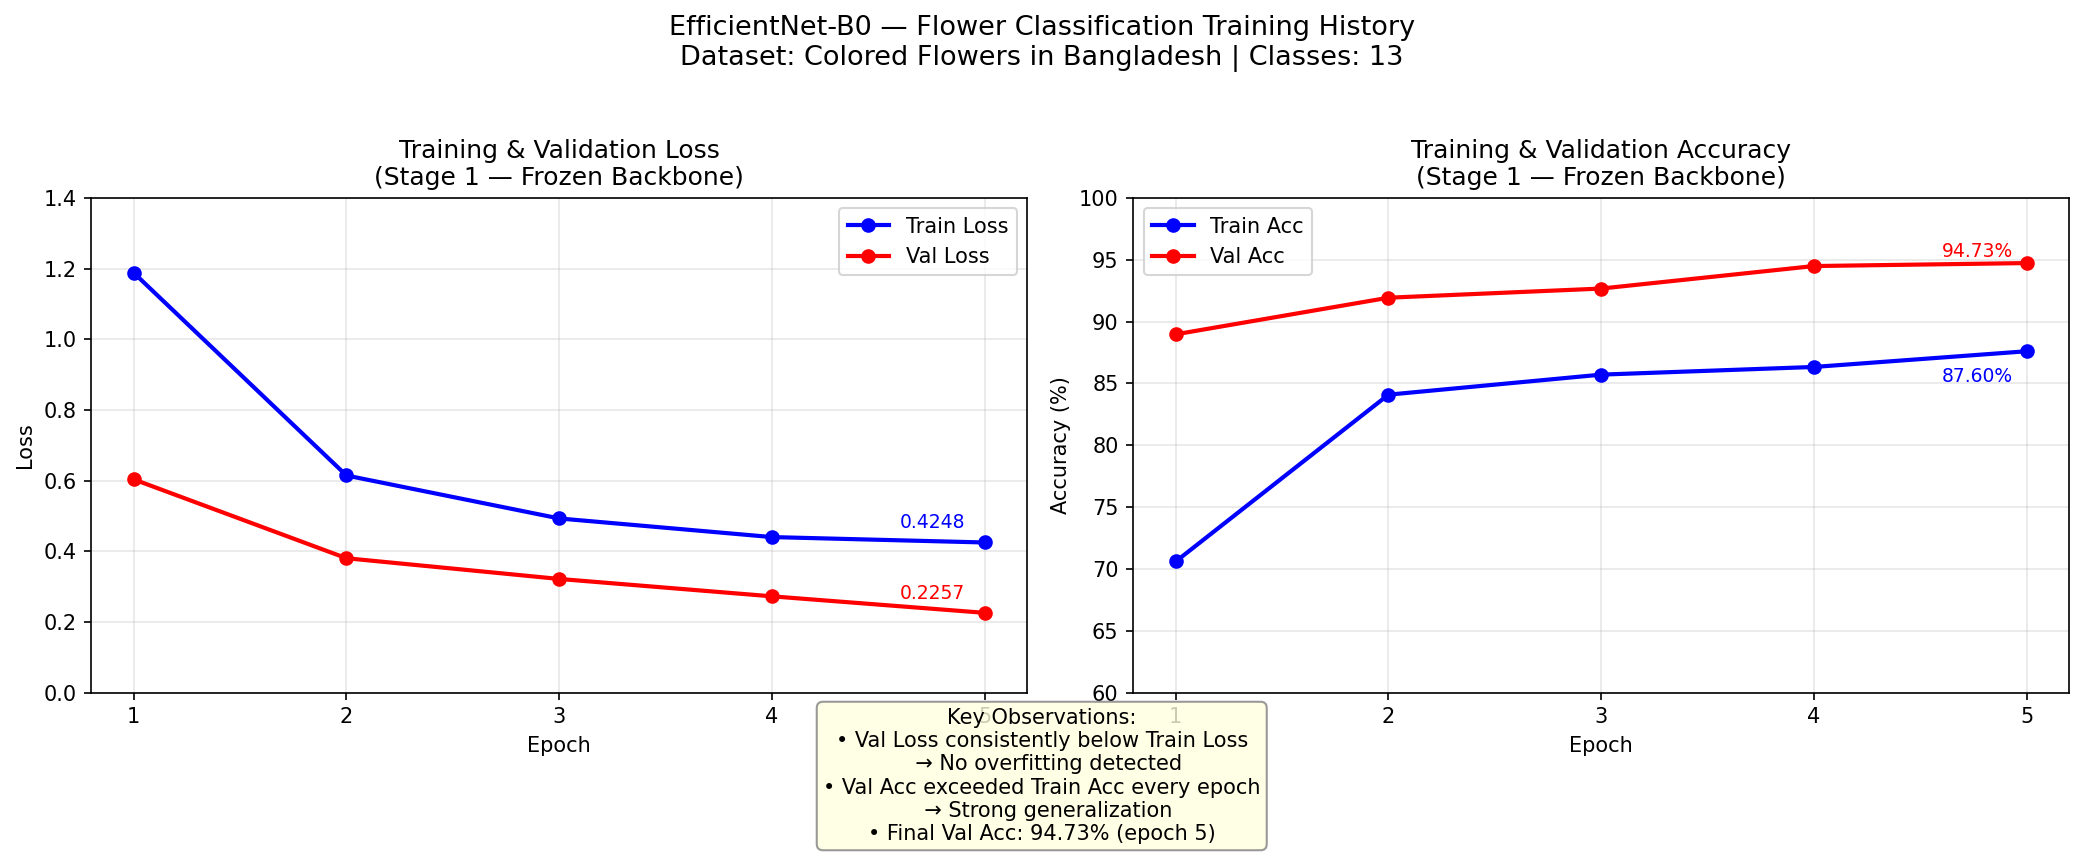

In [2]:
from IPython.display import Image as IPImage
import os

print("Training History — Loss and Accuracy curves")
print("Note: Val metrics consistently better than Train")
print("→ Strong generalization, no overfitting\n")
IPImage(filename=os.path.join('..', 'results', 'plots', 'training_history.png'), width=900)

Cell 10 — Per Class F1 Plot

Per-Class F1 Scores on Test Set
12/13 classes above 0.92 F1
Only Rose below 0.90 due to high visual variety



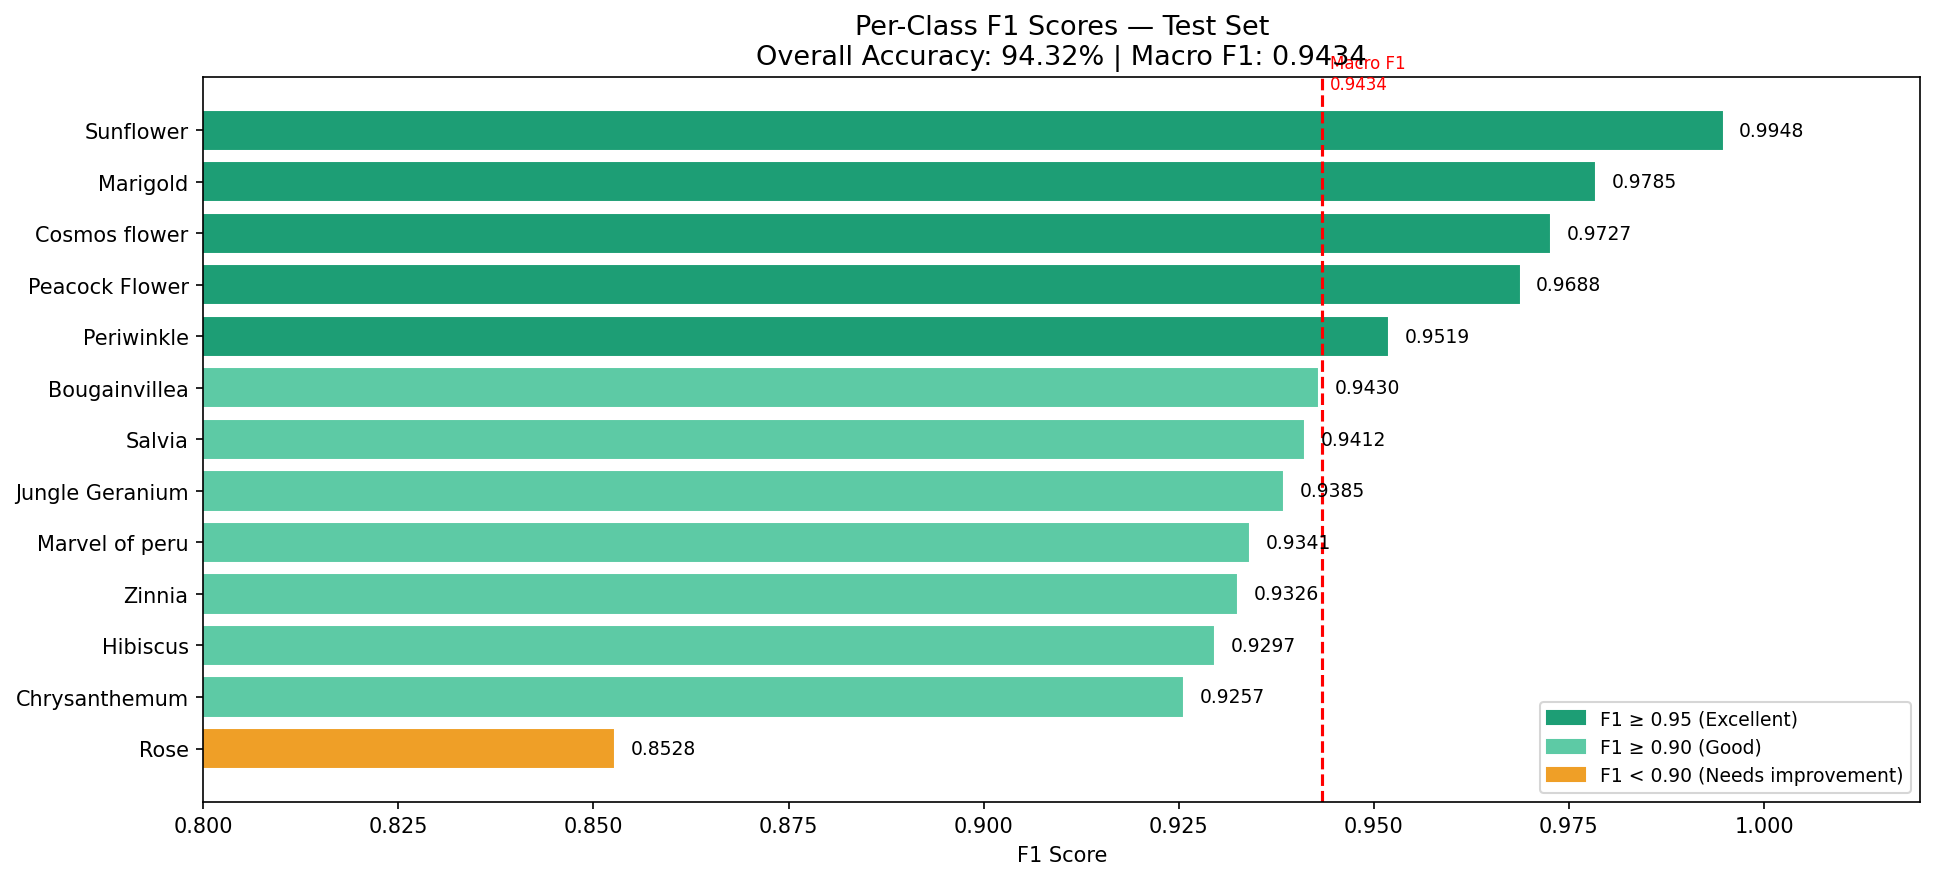

In [3]:
from IPython.display import Image as IPImage
import os

print("Per-Class F1 Scores on Test Set")
print("12/13 classes above 0.92 F1")
print("Only Rose below 0.90 due to high visual variety\n")
IPImage(filename=os.path.join('..', 'results', 'plots', 'per_class_f1.png'), width=900)